In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('customer_churn_nn.csv')
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (2000, 17)


In [4]:
print(df.dtypes)

customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [5]:
print(df['churn'].value_counts())

churn
0    1969
1      31
Name: count, dtype: int64


In [6]:
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [7]:
print(df.describe())

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000            0.000000       0.

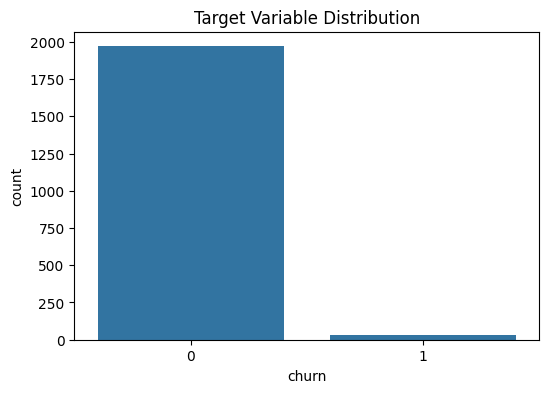

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)
plt.title('Target Variable Distribution')
plt.show()

The dataset was loaded and explored. It contains customer-related features used to predict churn. Basic checks included dataset shape, data types, missing values, summary statistics, and the distribution of the target variable (churn).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
X = df.drop('churn', axis=1)
y = df['churn']

In [13]:
X = X.fillna(X.median(numeric_only=True))

In [14]:
X = pd.get_dummies(X, drop_first=True)

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1600, 2023)
Testing data shape: (400, 2023)


In preprocessing, missing values were handled using median imputation. Categorical variables were converted into numeric form using one-hot encoding. Numerical features were standardized using StandardScaler so that all features are on a similar scale. Finally, the dataset was split into training and testing sets for model building.

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [18]:
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Second hidden layer
model.add(Dense(8, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        32,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,529 (127.07 KB)

 Trainable params: 32,529 (127.07 KB)

 Non-trainable params: 0 (0.00 B)

A feed-forward neural network was created using TensorFlow/Keras. The model contains an input layer, two hidden layers with ReLU activation, and an output layer with sigmoid activation for binary classification. Binary cross-entropy was used as the loss function and Adam as the optimizer.

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9383 - loss: 0.3587 - val_accuracy: 0.9500 - val_loss: 0.3178
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9852 - loss: 0.1034 - val_accuracy: 0.9594 - val_loss: 0.3136
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9859 - loss: 0.0676 - val_accuracy: 0.9781 - val_loss: 0.3090
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9867 - loss: 0.0520 - val_accuracy: 0.9781 - val_loss: 0.3056
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9867 - loss: 0.0406 - val_accuracy: 0.9781 - val_loss: 0.3018
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9867 - loss: 0.0327 - val_accuracy: 0.9781 - val_loss: 0.2980
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9867 - loss: 0.0269 - val_accuracy: 0.9781 - val_loss: 0.2958
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9867 - loss: 0.0229 - val_accuracy: 0.9781 - va

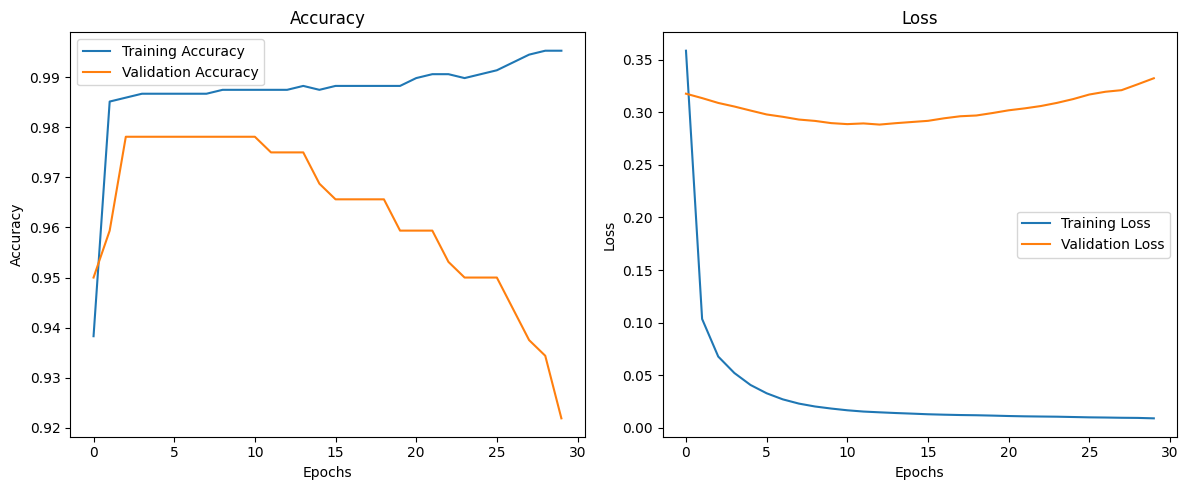

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9175 - loss: 0.3483  
Testing Loss: 0.34834617376327515
Testing Accuracy: 0.9175000190734863


In [24]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


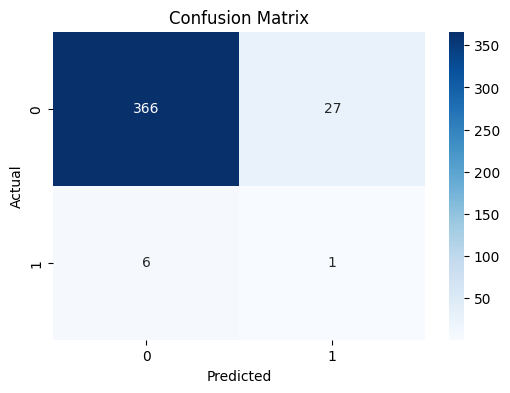

In [38]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("evaluation_outputs.png")
plt.show()

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.96       393
           1       0.04      0.14      0.06         7

    accuracy                           0.92       400
   macro avg       0.51      0.54      0.51       400
weighted avg       0.97      0.92      0.94       400



The neural network model was trained using the training dataset and evaluated on the testing dataset. Training and validation accuracy/loss were plotted to monitor learning. The confusion matrix and classification report were used to assess classification performance. The model performed satisfactorily for predicting the target variable.

In [27]:
model_1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_1.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

history_1 = model_1.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model_2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_2.compile(optimizer=Adam(learning_rate=0.0005),
                loss='binary_crossentropy',
                metrics=['accuracy'])

history_2 = model_2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

In [29]:
model_3 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model_3.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

history_3 = model_3.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

In [30]:
import pandas as pd

comparison = pd.DataFrame({
    'Experiment': ['Experiment 1', 'Experiment 2', 'Experiment 3'],
    'Hidden Layers': ['16-8', '32-16', '64-32'],
    'Activation': ['ReLU', 'ReLU', 'Tanh'],
    'Learning Rate': [0.001, 0.0005, 0.001],
    'Batch Size': [32, 16, 64],
    'Epochs': [30, 50, 40],
    'Validation Accuracy': [
        max(history_1.history['val_accuracy']),
        max(history_2.history['val_accuracy']),
        max(history_3.history['val_accuracy'])
    ]
})

comparison

,Experiment,Hidden Layers,Activation,Learning Rate,Batch Size,Epochs,Validation Accuracy
0,Experiment 1,16-8,ReLU,0.0010,32,30,0.881250
1,Experiment 2,32-16,ReLU,0.0005,16,50,0.978125
2,Experiment 3,64-32,Tanh,0.0010,64,40,0.237500


In [31]:
comparison.to_csv('model_comparison_table.csv', index=False)

In [32]:
import os

os.makedirs("results", exist_ok=True)
print("results folder created")

results folder created


In [33]:
comparison.to_csv("results/model_comparison_table.csv", index=False)
print("model_comparison_table.csv saved")

model_comparison_table.csv saved
